In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.style import set_plot_style, COLORS, fa
from src.utils.plot_utils import save_figure

set_plot_style()

DATA_PATH = "../data/raw/divar.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

In [2]:
trend = df[["created_at_month", "price_value"]].copy()

trend["created_at_month"] = pd.to_datetime(trend["created_at_month"])

trend.head()

,created_at_month,price_value
0,2024-08-01,NaN
1,2024-05-01,8.500000e+09
2,2024-10-01,NaN
3,2024-06-01,NaN
4,2024-05-01,5.750000e+09


In [3]:
import jdatetime

trend["jalali_year"] = trend["created_at_month"].apply(
    lambda d: jdatetime.date.fromgregorian(date=d.date()).year
)

In [4]:
trend.groupby("jalali_year").size()

jalali_year
1398         1
1399         2
1400         9
1401       120
1402      5664
1403    994204
dtype: int64

<p dir="rtl">


بررسی اولیه نشان داد که مجموعه داده از نظر زمانی نامتوازن است و بیش از ۹۹٪ آگهی‌ها مربوط به سال ۱۴۰۳ هستند. بنابراین محاسبه و مقایسه میانگین قیمت حقیقی برای سال‌های ۱۴۰۰ تا ۱۴۰۲ از نظر آماری قابل اتکا نیست و نتایج این سال‌ها باید با احتیاط تفسیر شوند.

</p>

In [5]:
trend = trend[trend["jalali_year"].between(1400, 1403)].copy()

In [6]:
nominal_price = (
    trend.dropna(subset=["price_value"])
    .groupby("jalali_year", as_index=False)["price_value"]
    .mean()
    .rename(columns={"price_value": "nominal_price"})
)
nominal_price

,jalali_year,nominal_price
0,1400,1.066667e+09
1,1401,1.882049e+10
2,1402,7.918916e+09
3,1403,1.743388e+10


In [7]:
cpi = {
    1400: 100.00,
    1401: 143.49,
    1402: 207.45,
    1403: 274.78,
}

In [8]:
nominal_price["cpi"] = nominal_price["jalali_year"].map(cpi)

In [9]:
BASE_CPI = 100

nominal_price["real_price"] = (
    nominal_price["nominal_price"] * BASE_CPI / nominal_price["cpi"]
)

In [10]:
nominal_price

,jalali_year,nominal_price,cpi,real_price
0,1400,1.066667e+09,100.00,1.066667e+09
1,1401,1.882049e+10,143.49,1.311624e+10
2,1402,7.918916e+09,207.45,3.817265e+09
3,1403,1.743388e+10,274.78,6.344668e+09


Figure saved -> D:\Quera\Exercises\project01\divar-real-estate-ml\reports\figures\real_price_trend.png


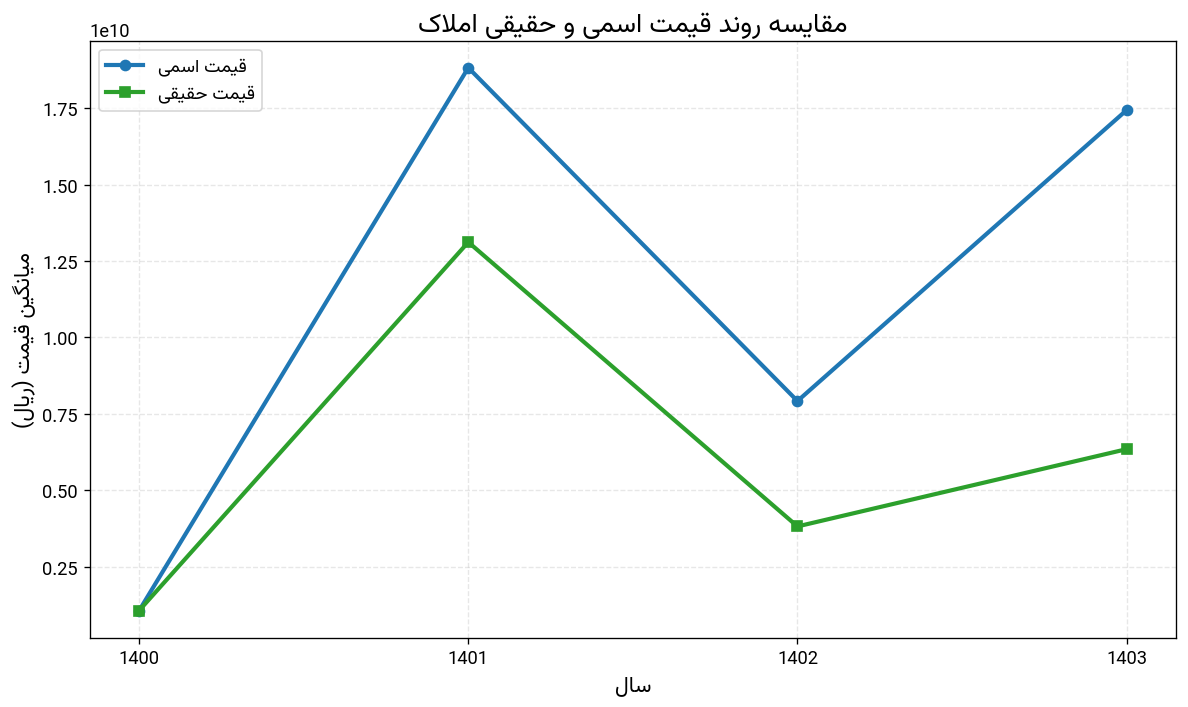

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    nominal_price["jalali_year"],
    nominal_price["nominal_price"],
    marker="o",
    color=COLORS["trend"],
    label=fa("قیمت اسمی"),
)

plt.plot(
    nominal_price["jalali_year"],
    nominal_price["real_price"],
    marker="s",
    color=COLORS["comparison"],
    label=fa("قیمت حقیقی"),
)

plt.title(fa("مقایسه روند قیمت اسمی و حقیقی املاک"))

plt.xlabel(fa("سال"))

plt.ylabel(fa("میانگین قیمت (ریال)"))

plt.xticks(nominal_price["jalali_year"])

plt.legend()

plt.tight_layout()

save_figure("real_price_trend")

plt.show()

<p dir="rtl">

با مقایسه روند قیمت اسمی و قیمت حقیقی مشاهده می‌شود که افزایش قیمت اسمی لزوماً به معنای افزایش ارزش واقعی املاک نیست. پس از تعدیل قیمت‌ها با شاخص قیمت مصرف‌کننده (CPI)، بخشی از رشد مشاهده‌شده ناشی از تورم حذف می‌شود و روند قیمت حقیقی تصویر دقیق‌تری از تغییرات واقعی ارزش بازار ارائه می‌دهد.

</p>